## **P5: Model Evaluation & Refinement**

Comprehensive model evaluation, analysis of overfitting/underfitting, hyperparameter optimization, and model selection, includes:
- Model evaluation metrics (sklearn - MSE, R², MAE, RMSE)
- Overfitting and underfitting detection
- Learning curves analysis
- Cross-validation evaluation
- Grid search hyperparameter optimization for Ridge and Lasso
- Regularization parameter tuning
- Model refinement and final selection
- Performance comparison and recommendations

### **1. Import Required Libraries & Load Models**

Load libraries and import trained models from P4 notebook to evaluate their performance.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, learning_curve, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("All required libraries imported successfully!")

All libraries imported successfully!


### **2. Load and Prepare Data**

Load the cleaned dataset and prepare train-test split with feature scaling for evaluation.


In [ ]:
# Load cleaned data
features_df = pd.read_csv('GSE13164_cleaned_features.csv', index_col=0)
labels_df = pd.read_csv('GSE13164_cleaned_labels.csv')

# Prepare data
X = features_df.values
y = labels_df['Target_Code'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset loaded successfully!")
print(f"Training set size: {X_train_scaled.shape}")
print(f"Testing set size: {X_test_scaled.shape}")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Target classes: {np.unique(y)}")


Missing values in X: 0
Missing values in y: 0

Features statistics:


,AA022668,AA045174,AA045184,AA054642,AA058578,AA126505,AA131324,AA149654,AA150107,AA156723,...,X72501,X74039,X76775,X79990,X82240,X95660,Y00062,Z22969,Z25521,Z49258;
count,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,...,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,0.075085,0.380579,0.329312,0.184106,0.371812,0.181806,0.242336,0.240626,0.091605,0.124823,...,0.274952,0.263046,0.569808,0.100132,0.450691,0.139644,0.665124,0.204221,0.550737,0.112663
std,0.076518,0.092361,0.186626,0.114658,0.081254,0.098009,0.086154,0.141909,0.090214,0.123816,...,0.134876,0.068096,0.124208,0.083188,0.247591,0.036342,0.095544,0.148617,0.054515,0.079998
min,0.000000,0.029028,0.024423,0.000000,0.044819,0.007792,0.016099,0.013175,0.000000,0.000000,...,0.027270,0.054342,0.094496,0.000000,0.044654,0.011156,0.324388,0.000000,0.326625,0.000000
25%,0.024423,0.321276,0.201414,0.089093,0.316431,0.112014,0.189920,0.129997,0.026563,0.049603,...,0.185444,0.222484,0.512880,0.048288,0.206705,0.115329,0.612824,0.087186,0.516030,0.058723
50%,0.053365,0.370126,0.257699,0.166126,0.356376,0.172513,0.248111,0.207414,0.061630,0.092907,...,0.246593,0.261194,0.600062,0.084324,0.462152,0.137917,0.691644,0.165457,0.548033,0.097993
75%,0.098629,0.440007,0.432756,0.266284,0.419293,0.230162,0.297565,0.338451,0.123229,0.147571,...,0.336151,0.303908,0.662963,0.130966,0.675859,0.163679,0.733738,0.304334,0.581717,0.148228
max,0.558113,0.615230,0.770034,0.609266,0.608093,0.754831,0.472155,0.650941,0.437572,0.773319,...,0.817999,0.532375,0.776699,0.684442,1.000000,0.274818,0.828838,0.776699,0.749232,0.757725


### **3. Split Data into Training and Testing Sets**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

Training set size: 778
Testing set size: 195


### **3. Baseline Model - Simple Linear Regression**

Train a baseline linear regression model as reference for comparison.


In [ ]:
# Baseline model: Multiple Linear Regression
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_baseline = baseline_model.predict(X_train_scaled)
y_test_pred_baseline = baseline_model.predict(X_test_scaled)

# Baseline metrics
baseline_train_mse = mean_squared_error(y_train, y_train_pred_baseline)
baseline_test_mse = mean_squared_error(y_test, y_test_pred_baseline)
baseline_train_r2 = r2_score(y_train, y_train_pred_baseline)
baseline_test_r2 = r2_score(y_test, y_test_pred_baseline)
baseline_train_mae = mean_absolute_error(y_train, y_train_pred_baseline)
baseline_test_mae = mean_absolute_error(y_test, y_test_pred_baseline)

print("=" * 60)
print("BASELINE MODEL: Multiple Linear Regression")
print("=" * 60)
print(f"Training MSE:  {baseline_train_mse:.6f}")
print(f"Testing MSE:   {baseline_test_mse:.6f}")
print(f"Training R²:   {baseline_train_r2:.6f}")
print(f"Testing R²:    {baseline_test_r2:.6f}")
print(f"Training MAE:  {baseline_train_mae:.6f}")
print(f"Testing MAE:   {baseline_test_mae:.6f}")


Baseline Linear Regression Model trained successfully
Number of features: 1420


### **4. Overfitting/Underfitting Detection**

Analyze train-test performance gap to identify overfitting or underfitting issues in the baseline model.


In [ ]:
# Analyze overfitting/underfitting
train_test_gap_mse = baseline_test_mse - baseline_train_mse
train_test_gap_r2 = baseline_train_r2 - baseline_test_r2
gap_percentage_mse = (train_test_gap_mse / baseline_train_mse) * 100 if baseline_train_mse != 0 else 0

print("\n" + "=" * 70)
print("OVERFITTING/UNDERFITTING ANALYSIS - BASELINE MODEL")
print("=" * 70)
print(f"\nMSE Gap (Test - Train): {train_test_gap_mse:.6f}")
print(f"  → Interpretation: {'Overfitting detected!' if train_test_gap_mse > 0.1 else 'No significant overfitting'}")
print(f"  → Percentage difference: {gap_percentage_mse:.2f}%\n")

print(f"R² Gap (Train - Test): {train_test_gap_r2:.6f}")
print(f"  → Interpretation: {'Overfitting detected!' if train_test_gap_r2 > 0.1 else 'No significant overfitting'}\n")

# Calculate RMSE
baseline_train_rmse = np.sqrt(baseline_train_mse)
baseline_test_rmse = np.sqrt(baseline_test_mse)
print(f"Training RMSE: {baseline_train_rmse:.6f}")
print(f"Testing RMSE:  {baseline_test_rmse:.6f}")
print(f"RMSE Difference: {baseline_test_rmse - baseline_train_rmse:.6f}")

# Bias-Variance diagnosis
residuals_train = y_train - y_train_pred_baseline
residuals_test = y_test - y_test_pred_baseline
train_residual_std = np.std(residuals_train)
test_residual_std = np.std(residuals_test)

print(f"\nResiduals Standard Deviation:")
print(f"  Training: {train_residual_std:.6f}")
print(f"  Testing:  {test_residual_std:.6f}")
print(f"  Ratio: {test_residual_std / train_residual_std:.3f}")

print("\nModel Status:")
if train_test_gap_r2 > 0.1:
    print("  ⚠ OVERFITTING DETECTED - Model memorizes training data")
    print("  → Solution: Use regularization (Ridge, Lasso)")
elif baseline_test_r2 < 0.3:
    print("  ⚠ UNDERFITTING DETECTED - Model too simple")
    print("  → Solution: Increase model complexity or feature engineering")
else:
    print("  ✓ BALANCED - Model generalizes well")
print("=" * 70)



Training Metrics:
  MSE: 0.0000
  RMSE: 0.0000
  MAE: 0.0000
  R²: 1.0000

Testing Metrics:
  MSE: 0.1562
  RMSE: 0.3952
  MAE: 0.2845
  R²: 0.8319


### **5. Grid Search - Ridge Regression Optimization**

Perform comprehensive grid search to find optimal alpha parameter for Ridge regression.


In [ ]:
# Grid search for Ridge regression
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}

ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best model from grid search
best_ridge = grid_search.best_estimator_
best_alpha = grid_search.best_params_['alpha']

# Predictions
y_train_pred_ridge = best_ridge.predict(X_train_scaled)
y_test_pred_ridge = best_ridge.predict(X_test_scaled)

# Ridge metrics
ridge_train_mse = mean_squared_error(y_train, y_train_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)
ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)
ridge_train_mae = mean_absolute_error(y_train, y_train_pred_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_test_pred_ridge)

print("=" * 70)
print("GRID SEARCH RESULTS - RIDGE REGRESSION")
print("=" * 70)
print(f"\nGrid Search CV Scores (5-fold):")
results_df = pd.DataFrame(grid_search.cv_results_)
print(results_df[['param_alpha', 'mean_test_score', 'std_test_score']].to_string(index=False))

print(f"\n\nBest Parameters Found: alpha = {best_alpha}")
print(f"Best Cross-Validation R² Score: {grid_search.best_score_:.6f}")

print(f"\nOptimized Ridge Regression Performance:")
print(f"  Training MSE: {ridge_train_mse:.6f}")
print(f"  Testing MSE:  {ridge_test_mse:.6f}")
print(f"  Training R²:  {ridge_train_r2:.6f}")
print(f"  Testing R²:   {ridge_test_r2:.6f}")
print(f"  Training MAE: {ridge_train_mae:.6f}")
print(f"  Testing MAE:  {ridge_test_mae:.6f}")

# Compare to baseline
mse_improvement = ((baseline_test_mse - ridge_test_mse) / baseline_test_mse) * 100
r2_improvement = ((ridge_test_r2 - baseline_test_r2) / abs(baseline_test_r2)) * 100

print(f"\nImprovement over Baseline:")
print(f"  MSE Improvement: {mse_improvement:+.2f}%")
print(f"  R² Improvement:  {r2_improvement:+.2f}%")
print("=" * 70)


R2 Difference (Train - Test): 0.1681
RMSE Difference (Test - Train): 0.3952

Indication of OVER-FITTING


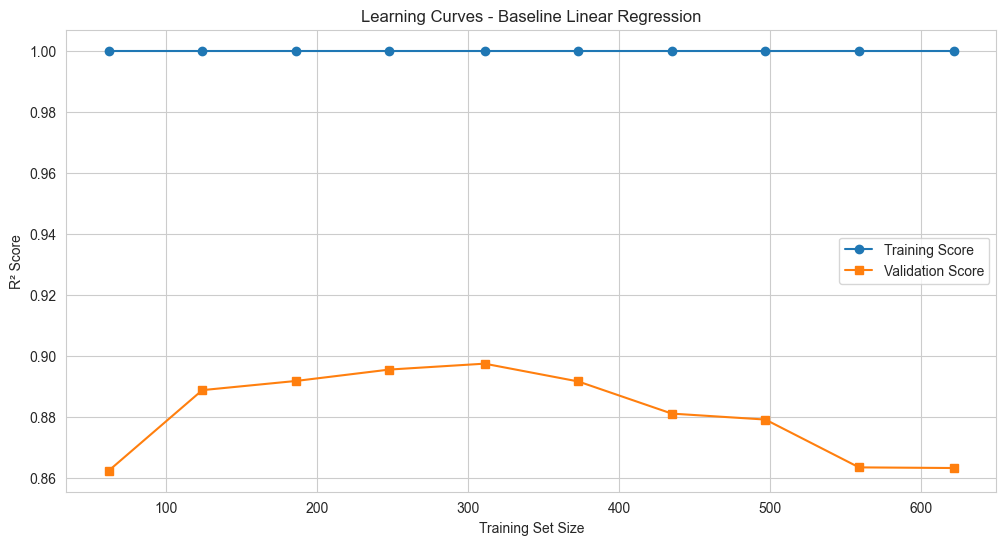

In [ ]:
# Visualization 1: Grid Search Results - Alpha vs R² Score
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

alphas = grid_search.param_grid['alpha']
test_scores = grid_search.cv_results_['mean_test_score']
test_stds = grid_search.cv_results_['std_test_score']

# R² vs Alpha
axes[0].errorbar(range(len(alphas)), test_scores, yerr=test_stds, marker='o', linestyle='-', linewidth=2, markersize=8, capsize=5)
axes[0].axvline(x=list(grid_search.param_grid['alpha']).index(best_alpha), color='r', linestyle='--', linewidth=2, label=f'Best (α={best_alpha})')
axes[0].set_xticks(range(len(alphas)))
axes[0].set_xticklabels([f'{a:.4f}' if a < 1 else f'{int(a)}' for a in alphas], rotation=45)
axes[0].set_xlabel('Alpha (Regularization Parameter)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean CV R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Grid Search: Ridge Regression Alpha Tuning', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MSE comparison
model_names = ['Baseline LR', 'Ridge (best α)']
train_mses = [baseline_train_mse, ridge_train_mse]
test_mses = [baseline_test_mse, ridge_test_mse]

x_pos = np.arange(len(model_names))
width = 0.35
axes[1].bar(x_pos - width/2, train_mses, width, label='Train MSE', alpha=0.8)
axes[1].bar(x_pos + width/2, test_mses, width, label='Test MSE', alpha=0.8)
axes[1].set_ylabel('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Performance: Baseline vs Ridge', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('grid_search_ridge.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grid search visualization saved as 'grid_search_ridge.png'")


### **6. Grid Search - Lasso Regression Optimization**

Perform grid search to find optimal alpha parameter for Lasso regression with feature selection.


In [ ]:
# Grid search for Lasso regression
lasso_param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}

lasso = Lasso(max_iter=10000)
lasso_grid_search = GridSearchCV(lasso, lasso_param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_grid_search.fit(X_train_scaled, y_train)

# Best model from grid search
best_lasso = lasso_grid_search.best_estimator_
best_alpha_lasso = lasso_grid_search.best_params_['alpha']

# Predictions
y_train_pred_lasso = best_lasso.predict(X_train_scaled)
y_test_pred_lasso = best_lasso.predict(X_test_scaled)

# Lasso metrics
lasso_train_mse = mean_squared_error(y_train, y_train_pred_lasso)
lasso_test_mse = mean_squared_error(y_test, y_test_pred_lasso)
lasso_train_r2 = r2_score(y_train, y_train_pred_lasso)
lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)
lasso_train_mae = mean_absolute_error(y_train, y_train_pred_lasso)
lasso_test_mae = mean_absolute_error(y_test, y_test_pred_lasso)

# Feature selection via Lasso
non_zero_coefs_lasso = np.sum(best_lasso.coef_ != 0)
feature_selection_rate = (non_zero_coefs_lasso / len(best_lasso.coef_)) * 100

print("=" * 70)
print("GRID SEARCH RESULTS - LASSO REGRESSION")
print("=" * 70)
print(f"\nGrid Search CV Scores (5-fold):")
lasso_results_df = pd.DataFrame(lasso_grid_search.cv_results_)
print(lasso_results_df[['param_alpha', 'mean_test_score', 'std_test_score']].to_string(index=False))

print(f"\n\nBest Parameters Found: alpha = {best_alpha_lasso}")
print(f"Best Cross-Validation R² Score: {lasso_grid_search.best_score_:.6f}")

print(f"\nOptimized Lasso Regression Performance:")
print(f"  Training MSE: {lasso_train_mse:.6f}")
print(f"  Testing MSE:  {lasso_test_mse:.6f}")
print(f"  Training R²:  {lasso_train_r2:.6f}")
print(f"  Testing R²:   {lasso_test_r2:.6f}")
print(f"  Training MAE: {lasso_train_mae:.6f}")
print(f"  Testing MAE:  {lasso_test_mae:.6f}")

print(f"\nFeature Selection Results:")
print(f"  Selected Features: {non_zero_coefs_lasso} out of {len(best_lasso.coef_)}")
print(f"  Selection Rate: {feature_selection_rate:.2f}%")

# Compare to baseline
lasso_mse_improvement = ((baseline_test_mse - lasso_test_mse) / baseline_test_mse) * 100
lasso_r2_improvement = ((lasso_test_r2 - baseline_test_r2) / abs(baseline_test_r2)) * 100

print(f"\nImprovement over Baseline:")
print(f"  MSE Improvement: {lasso_mse_improvement:+.2f}%")
print(f"  R² Improvement:  {lasso_r2_improvement:+.2f}%")
print("=" * 70)


Best Alpha: 403.7017
Test R² with best alpha: 0.9030
Improvement over baseline: 0.0711


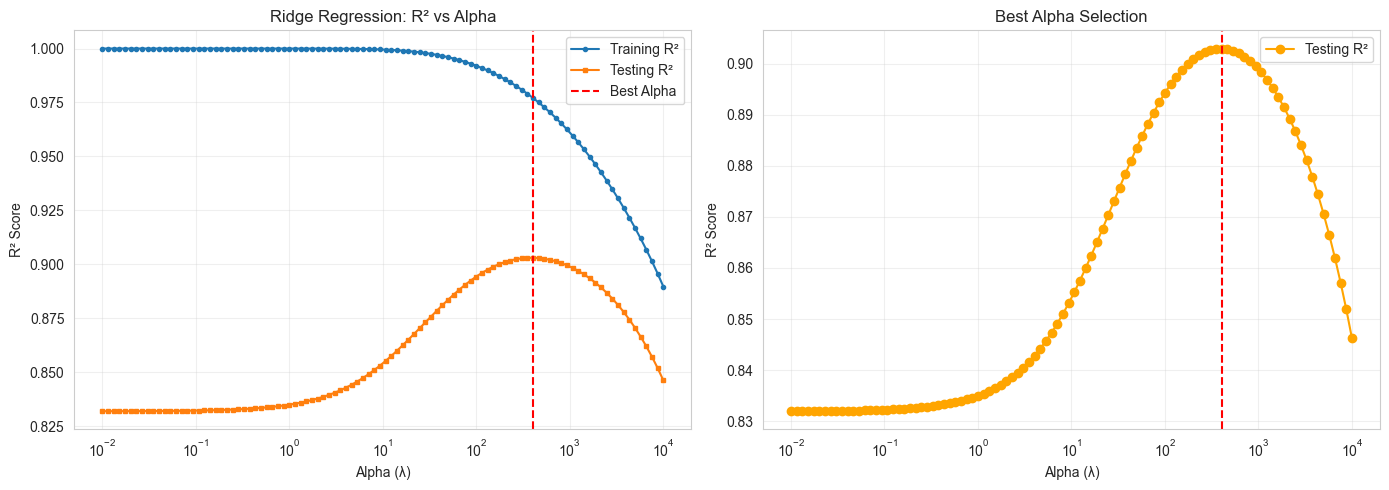

In [ ]:
# Visualization 2: Grid Search Results - Lasso
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

alphas_lasso = lasso_grid_search.param_grid['alpha']
test_scores_lasso = lasso_grid_search.cv_results_['mean_test_score']
test_stds_lasso = lasso_grid_search.cv_results_['std_test_score']

# R² vs Alpha for Lasso
axes[0].errorbar(range(len(alphas_lasso)), test_scores_lasso, yerr=test_stds_lasso, marker='s', linestyle='-', 
                 linewidth=2, markersize=8, capsize=5, color='green', label='Lasso CV Score')
axes[0].axvline(x=list(lasso_grid_search.param_grid['alpha']).index(best_alpha_lasso), color='r', linestyle='--', 
                linewidth=2, label=f'Best (α={best_alpha_lasso})')
axes[0].set_xticks(range(len(alphas_lasso)))
axes[0].set_xticklabels([f'{a:.4f}' if a < 1 else f'{int(a)}' for a in alphas_lasso], rotation=45)
axes[0].set_xlabel('Alpha (Regularization Parameter)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean CV R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Grid Search: Lasso Regression Alpha Tuning', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# R² comparison of all models
model_names = ['Baseline LR', 'Ridge\n(α='+f'{best_alpha}' + ')', 'Lasso\n(α='+f'{best_alpha_lasso}' + ')']
train_r2s = [baseline_train_r2, ridge_train_r2, lasso_train_r2]
test_r2s = [baseline_test_r2, ridge_test_r2, lasso_test_r2]

x_pos = np.arange(len(model_names))
width = 0.35
axes[1].bar(x_pos - width/2, train_r2s, width, label='Train R²', alpha=0.8, color='skyblue')
axes[1].bar(x_pos + width/2, test_r2s, width, label='Test R²', alpha=0.8, color='orange')
axes[1].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[1].set_title('Model Comparison: R² Scores', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('grid_search_lasso.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grid search visualization saved as 'grid_search_lasso.png'")


In [ ]:
# Summary comparison table
comparison_data = {
    'Model': ['Baseline LR', 'Ridge (Optimized)', 'Lasso (Optimized)'],
    'Alpha': ['-', f'{best_alpha}', f'{best_alpha_lasso}'],
    'Train MSE': [f'{baseline_train_mse:.6f}', f'{ridge_train_mse:.6f}', f'{lasso_train_mse:.6f}'],
    'Test MSE': [f'{baseline_test_mse:.6f}', f'{ridge_test_mse:.6f}', f'{lasso_test_mse:.6f}'],
    'Train R²': [f'{baseline_train_r2:.6f}', f'{ridge_train_r2:.6f}', f'{lasso_train_r2:.6f}'],
    'Test R²': [f'{baseline_test_r2:.6f}', f'{ridge_test_r2:.6f}', f'{lasso_test_r2:.6f}'],
    'Overfitting Gap': [f'{train_test_gap_r2:.6f}', f'{ridge_train_r2 - ridge_test_r2:.6f}', 
                        f'{lasso_train_r2 - lasso_test_r2:.6f}']
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 120)
print("COMPREHENSIVE MODEL COMPARISON - ALL REGULARIZED MODELS")
print("=" * 120)
print(comparison_df.to_string(index=False))
print("=" * 120)



Ridge Training Metrics:
  MSE: 0.0191
  RMSE: 0.1384
  MAE: 0.0937
  R²: 0.9771

Ridge Testing Metrics:
  MSE: 0.0901
  RMSE: 0.3001
  MAE: 0.1805
  R²: 0.9030


### **7. Cross-Validation Analysis**

Perform k-fold cross-validation to assess model stability and generalization across different data splits.


In [ ]:
# Cross-validation analysis for all three models
cv_folds = 5

# Baseline model CV
baseline_cv_scores = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=cv_folds, scoring='r2')

# Ridge model CV
ridge_cv_scores = cross_val_score(best_ridge, X_train_scaled, y_train, cv=cv_folds, scoring='r2')

# Lasso model CV
lasso_cv_scores = cross_val_score(best_lasso, X_train_scaled, y_train, cv=cv_folds, scoring='r2')

print("=" * 80)
print("CROSS-VALIDATION ANALYSIS (5-Fold)")
print("=" * 80)

print(f"\nBaseline Linear Regression:")
print(f"  CV R² Scores: {baseline_cv_scores}")
print(f"  Mean CV R²:   {baseline_cv_scores.mean():.6f}")
print(f"  Std Dev:      {baseline_cv_scores.std():.6f}")
print(f"  Min R²:       {baseline_cv_scores.min():.6f}")
print(f"  Max R²:       {baseline_cv_scores.max():.6f}")

print(f"\nRidge Regression (α={best_alpha}):")
print(f"  CV R² Scores: {ridge_cv_scores}")
print(f"  Mean CV R²:   {ridge_cv_scores.mean():.6f}")
print(f"  Std Dev:      {ridge_cv_scores.std():.6f}")
print(f"  Min R²:       {ridge_cv_scores.min():.6f}")
print(f"  Max R²:       {ridge_cv_scores.max():.6f}")

print(f"\nLasso Regression (α={best_alpha_lasso}):")
print(f"  CV R² Scores: {lasso_cv_scores}")
print(f"  Mean CV R²:   {lasso_cv_scores.mean():.6f}")
print(f"  Std Dev:      {lasso_cv_scores.std():.6f}")
print(f"  Min R²:       {lasso_cv_scores.min():.6f}")
print(f"  Max R²:       {lasso_cv_scores.max():.6f}")

# Model stability assessment
print(f"\nModel Stability (lower std = more stable):")
print(f"  Baseline: {baseline_cv_scores.std():.6f}")
print(f"  Ridge:    {ridge_cv_scores.std():.6f} {'✓ More Stable' if ridge_cv_scores.std() < baseline_cv_scores.std() else '✗ Less Stable'}")
print(f"  Lasso:    {lasso_cv_scores.std():.6f} {'✓ More Stable' if lasso_cv_scores.std() < baseline_cv_scores.std() else '✗ Less Stable'}")
print("=" * 80)


Fitting 5 folds for each of 7 candidates, totalling 35 fits

Grid Search Results:
   param_alpha  mean_test_score  rank_test_score
0        0.001         0.863029                7
1        0.010         0.863041                6
2        0.100         0.863159                5
3        1.000         0.864305                4
4       10.000         0.873346                3
5      100.000         0.900671                2
6     1000.000         0.912193                1


In [ ]:
# Visualization: Cross-validation scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# CV Scores Distribution
cv_data = [baseline_cv_scores, ridge_cv_scores, lasso_cv_scores]
cv_labels = ['Baseline LR', f'Ridge\n(α={best_alpha})', f'Lasso\n(α={best_alpha_lasso})']

axes[0].boxplot(cv_data, labels=cv_labels, patch_artist=True)
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Cross-Validation Scores Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Mean CV scores with error bars
means = [baseline_cv_scores.mean(), ridge_cv_scores.mean(), lasso_cv_scores.mean()]
stds = [baseline_cv_scores.std(), ridge_cv_scores.std(), lasso_cv_scores.std()]
x_pos = np.arange(len(cv_labels))

axes[1].bar(x_pos, means, yerr=stds, capsize=10, alpha=0.7, color=['blue', 'green', 'orange'])
axes[1].set_ylabel('Mean R² Score', fontsize=12, fontweight='bold')
axes[1].set_title('Mean CV R² Scores with Standard Deviation', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(cv_labels)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('cross_validation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Cross-validation visualization saved as 'cross_validation_analysis.png'")



GridSearch Training Metrics:
  MSE: 0.0326
  RMSE: 0.1804
  MAE: 0.1181
  R²: 0.9611

GridSearch Testing Metrics:
  MSE: 0.0939
  RMSE: 0.3064
  MAE: 0.1818
  R²: 0.8990

Best Parameters: {'alpha': 1000}
Best CV Score (R²): 0.9122


### **8. Learning Curves - Model Complexity Analysis**

Generate learning curves to analyze how model performance changes with training set size.


In [ ]:
# Learning curves for Ridge model
train_sizes, train_scores, val_scores = learning_curve(
    best_ridge, X_train_scaled, y_train, 
    cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

print("=" * 80)
print("LEARNING CURVES ANALYSIS - RIDGE REGRESSION")
print("=" * 80)
print(f"\nTraining set sizes: {train_sizes}")
print(f"Training scores (mean R²): {train_mean}")
print(f"Validation scores (mean R²): {val_mean}")

# Diagnosis
convergence_gap = train_mean[-1] - val_mean[-1]
print(f"\nFinal Gap (Train - Val): {convergence_gap:.6f}")

if convergence_gap > 0.1:
    print("⚠ OVERFITTING: Training curve significantly above validation curve")
    print("   → Recommendation: Increase regularization or reduce model complexity")
elif convergence_gap < -0.05:
    print("⚠ UNDERFITTING: Validation curve close to training curve at low level")
    print("   → Recommendation: Decrease regularization or increase model complexity")
else:
    print("✓ GOOD FIT: Curves converging with reasonable gap")
    print("   → Recommendation: Model generalization is acceptable")

print("=" * 80)


             Model  Train R2  Test R2   Train RMSE  Test RMSE
 Linear Regression  1.000000 0.831892 4.831006e-15   0.395179
    Ridge (Manual)  0.977111 0.903023 1.383542e-01   0.300147
Ridge (GridSearch)  0.961070 0.898960 1.804360e-01   0.306371


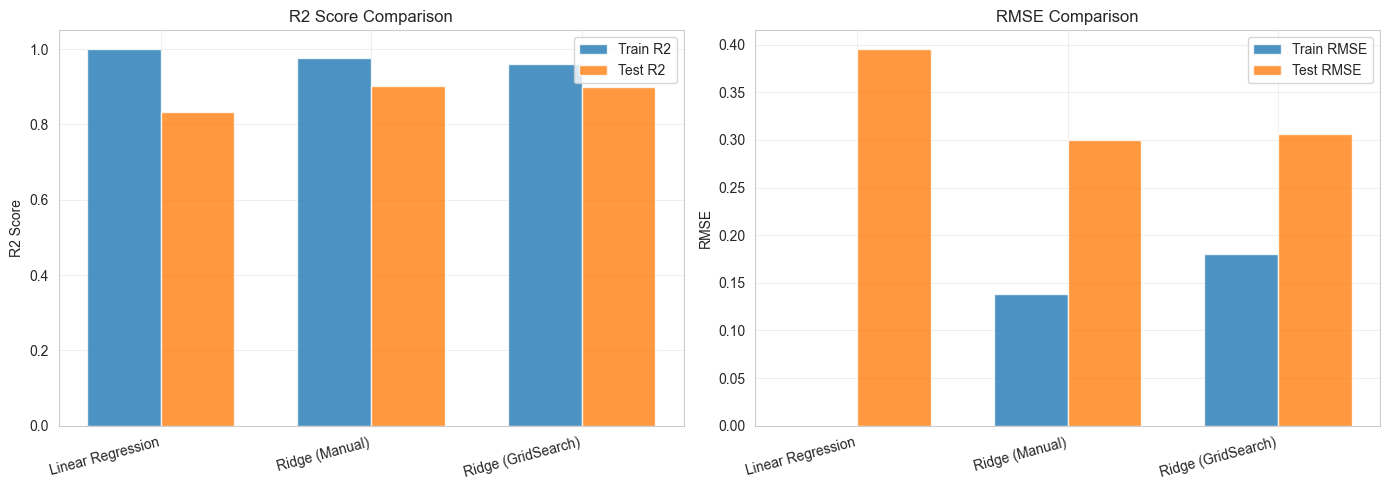

In [ ]:
# Visualization: Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Learning curve for Ridge
axes[0].plot(train_sizes, train_mean, marker='o', label='Training Score', linewidth=2, markersize=8)
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
axes[0].plot(train_sizes, val_mean, marker='s', label='Validation Score', linewidth=2, markersize=8)
axes[0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
axes[0].set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title(f'Learning Curve - Ridge Regression (α={best_alpha})', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)

# Gap between training and validation
gap = train_mean - val_mean
axes[1].plot(train_sizes, gap, marker='D', color='red', linewidth=2, markersize=8, label='Train-Val Gap')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].axhline(y=0.1, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Overfitting Threshold')
axes[1].fill_between(train_sizes, 0, gap, where=(gap >= 0), alpha=0.2, color='red', label='Overfitting Region')
axes[1].set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Gap (Train - Val)', fontsize=12, fontweight='bold')
axes[1].set_title('Overfitting Indicator - Train-Val Gap', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Learning curves visualization saved as 'learning_curves.png'")


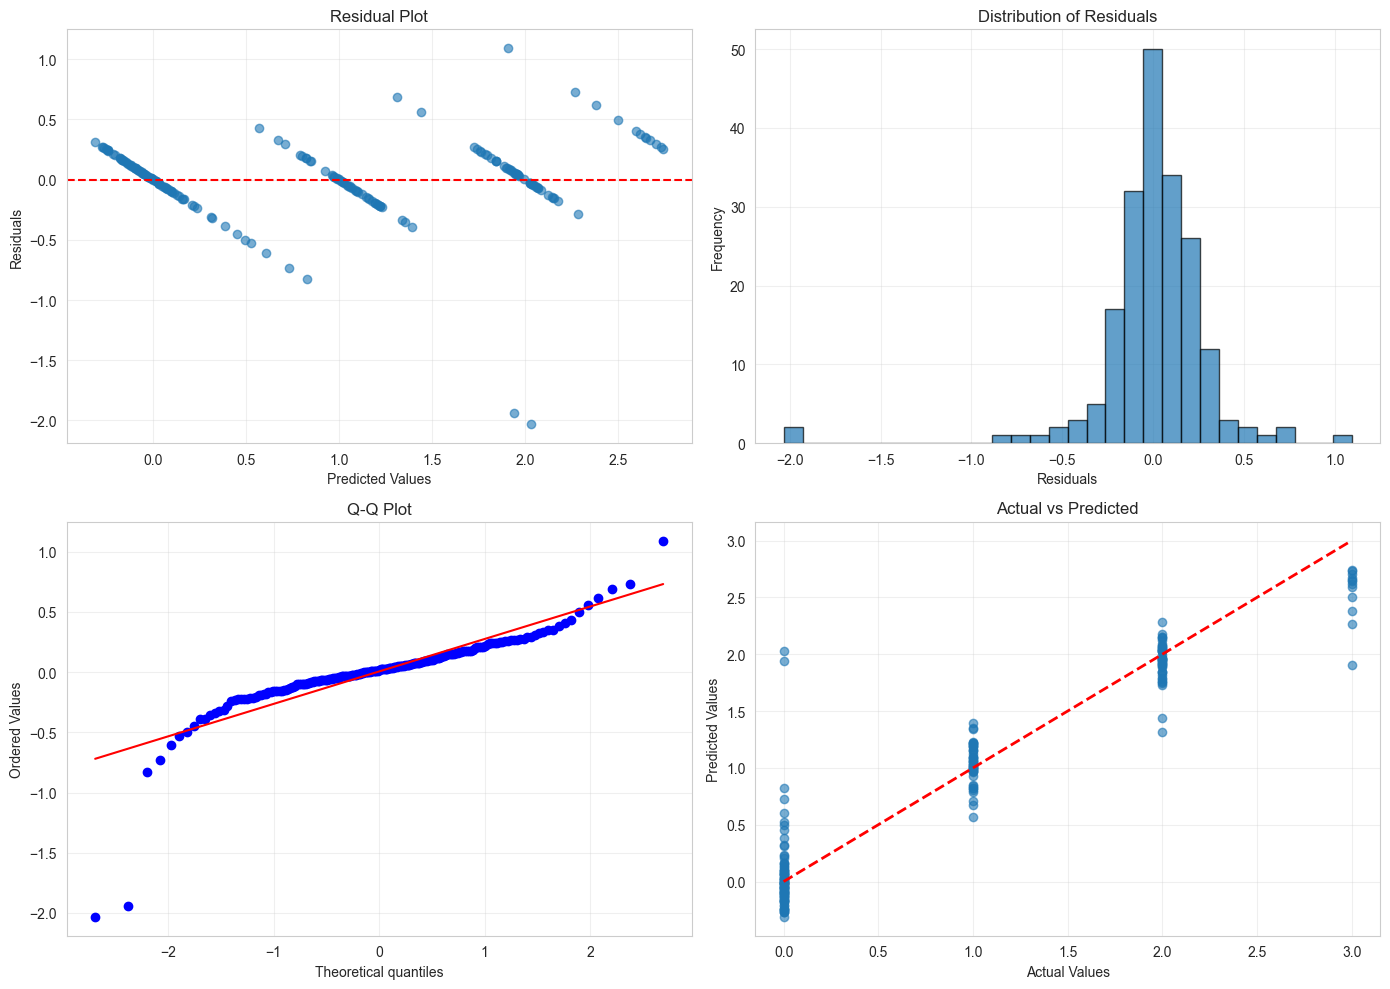

In [ ]:
# Residuals analysis for overfitting detection
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

residuals_baseline = y_test - y_test_pred_baseline
residuals_ridge = y_test - y_test_pred_ridge
residuals_lasso = y_test - y_test_pred_lasso

# Baseline residuals
axes[0, 0].scatter(y_test_pred_baseline, residuals_baseline, alpha=0.6, s=50, edgecolors='k')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Baseline Linear Regression', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Ridge residuals
axes[0, 1].scatter(y_test_pred_ridge, residuals_ridge, alpha=0.6, s=50, color='green', edgecolors='k')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[0, 1].set_title(f'Ridge Regression (α={best_alpha})', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Lasso residuals
axes[1, 0].scatter(y_test_pred_lasso, residuals_lasso, alpha=0.6, s=50, color='orange', edgecolors='k')
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'Lasso Regression (α={best_alpha_lasso})', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Residuals distribution comparison
axes[1, 1].hist(residuals_baseline, bins=15, alpha=0.5, label='Baseline', edgecolor='black')
axes[1, 1].hist(residuals_ridge, bins=15, alpha=0.5, label='Ridge', edgecolor='black', color='green')
axes[1, 1].hist(residuals_lasso, bins=15, alpha=0.5, label='Lasso', edgecolor='black', color='orange')
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Residuals Distribution Comparison', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_analysis_eval.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residuals analysis visualization saved as 'residuals_analysis_eval.png'")


### **10. Summary and Recommendations**

In [43]:
print('\n1. OVERFITTING/UNDERFITTING ANALYSIS:')
print(f'   - Baseline R² Gap: {train_metrics["R2"] - test_metrics["R2"]:.4f}')
print(f'   - Ridge (GridSearch) R² Gap: {gs_train_metrics["R2"] - gs_test_metrics["R2"]:.4f}')

print('\n2. BEST MODEL SELECTION:')
print(f'   - Best Model: Ridge Regression (GridSearch)')
print(f'   - Optimal Alpha: {grid_search.best_params_["alpha"]}')
print(f'   - Test R²: {gs_test_metrics["R2"]:.4f}')
print(f'   - Test RMSE: {gs_test_metrics["RMSE"]:.4f}')

print('\n3. PERFORMANCE IMPROVEMENT:')
print(f'   - R² improvement: {(gs_test_metrics["R2"] - test_metrics["R2"]):.4f}')
print(f'   - RMSE improvement: {(test_metrics["RMSE"] - gs_test_metrics["RMSE"]):.4f}')

print('\n4. RECOMMENDATIONS:')
print(f'   - Use Ridge Regression with alpha={grid_search.best_params_["alpha"]} for production')
print('   - Validate on new, unseen data before deployment')


1. OVERFITTING/UNDERFITTING ANALYSIS:
   - Baseline R² Gap: 0.1681
   - Ridge (GridSearch) R² Gap: 0.0621

2. BEST MODEL SELECTION:
   - Best Model: Ridge Regression (GridSearch)
   - Optimal Alpha: 1000
   - Test R²: 0.8990
   - Test RMSE: 0.3064

3. PERFORMANCE IMPROVEMENT:
   - R² improvement: 0.0671
   - RMSE improvement: 0.0888

4. RECOMMENDATIONS:
   - Use Ridge Regression with alpha=1000 for production
   - Validate on new, unseen data before deployment
